Intro to DataFrames

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.DataFrame([[1, 2, 3],[4, 5, 6],[7, 8, 9],[10, 11, 12],[13, 14, 15],[16, 17, 18]], columns=['A', 'B', 'C'])
print(df)

    A   B   C
0   1   2   3
1   4   5   6
2   7   8   9
3  10  11  12
4  13  14  15
5  16  17  18


In [4]:
df.head() #it show the first 5 rows of the dataframe

,A,B,C
0,1,2,3
1,4,5,6
2,7,8,9
3,10,11,12
4,13,14,15


In [5]:
df.tail() #it show the last 5 rows of the dataframe

,A,B,C
1,4,5,6
2,7,8,9
3,10,11,12
4,13,14,15
5,16,17,18


In [6]:
df.A #it show the column A of the dataframe

0     1
1     4
2     7
3    10
4    13
5    16
Name: A, dtype: int64

In [7]:
df.info() #it show the information of the dataframe

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       6 non-null      int64
 1   B       6 non-null      int64
 2   C       6 non-null      int64
dtypes: int64(3)
memory usage: 276.0 bytes


In [8]:
df.describe() #it show the statistical information of the dataframe

,A,B,C
count,6.000000,6.000000,6.000000
mean,8.500000,9.500000,10.500000
std,5.612486,5.612486,5.612486
min,1.000000,2.000000,3.000000
25%,4.750000,5.750000,6.750000
50%,8.500000,9.500000,10.500000
75%,12.250000,13.250000,14.250000
max,16.000000,17.000000,18.000000


Loading in Dataframes from files 


In [9]:
coffee = pd.read_csv('./warmup-data/coffee.csv')

In [10]:
coffee.head(10)

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25.0
1,Monday,Latte,15.0
2,Tuesday,Espresso,30.0
3,Tuesday,Latte,20.0
4,Wednesday,Espresso,35.0
5,Wednesday,Latte,NaN
6,Thursday,Espresso,40.0
7,Thursday,Latte,30.0
8,Friday,Espresso,45.0
9,Friday,Latte,35.0


In [11]:
coffee.describe()

,Units Sold
count,13.000000
mean,33.461538
std,9.439415
min,15.000000
25%,30.000000
50%,35.000000
75%,40.000000
max,45.000000


In [12]:
result = pd.read_parquet('./data/results.parquet')

Accessing Data with Pandas


In [13]:
print(coffee)

          Day Coffee Type  Units Sold
0      Monday    Espresso        25.0
1      Monday       Latte        15.0
2     Tuesday    Espresso        30.0
3     Tuesday       Latte        20.0
4   Wednesday    Espresso        35.0
5   Wednesday       Latte         NaN
6    Thursday    Espresso        40.0
7    Thursday       Latte        30.0
8      Friday    Espresso        45.0
9      Friday       Latte        35.0
10   Saturday    Espresso        45.0
11   Saturday       Latte        35.0
12     Sunday    Espresso        45.0
13     Sunday       Latte        35.0


In [14]:
coffee.isnull().sum() #1 value is missing in the 'units sold' column

Day            0
Coffee Type    0
Units Sold     1
dtype: int64

In [15]:
coffee.dropna() #it will drop the row which has missing value in the 'units sold' column . col 5 is dropped

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25.0
1,Monday,Latte,15.0
2,Tuesday,Espresso,30.0
3,Tuesday,Latte,20.0
4,Wednesday,Espresso,35.0
6,Thursday,Espresso,40.0
7,Thursday,Latte,30.0
8,Friday,Espresso,45.0
9,Friday,Latte,35.0
10,Saturday,Espresso,45.0


In [16]:
coffee['Units Sold'] = coffee['Units Sold'].fillna(coffee['Units Sold'].mean())

In [17]:
print(coffee)

          Day Coffee Type  Units Sold
0      Monday    Espresso   25.000000
1      Monday       Latte   15.000000
2     Tuesday    Espresso   30.000000
3     Tuesday       Latte   20.000000
4   Wednesday    Espresso   35.000000
5   Wednesday       Latte   33.461538
6    Thursday    Espresso   40.000000
7    Thursday       Latte   30.000000
8      Friday    Espresso   45.000000
9      Friday       Latte   35.000000
10   Saturday    Espresso   45.000000
11   Saturday       Latte   35.000000
12     Sunday    Espresso   45.000000
13     Sunday       Latte   35.000000


In [18]:
## To read an excel spreadsheet
olympics_data = pd.read_excel('./data/olympics-data.xlsx', sheet_name="results")

Filtering Data

In [19]:
from pathlib import Path

path = Path('./data/bios.csv')
print(path.resolve(), path.exists())

if path.exists():
    bios = pd.read_csv(path)
else:
    path = Path('data/bios.csv')
    print(path.resolve(), path.exists())

    if path.exists():
        bios = pd.read_csv(path)
    else:
        raise FileNotFoundError(f"CSV file not found: {path.resolve()}")

E:\Pandas\complete-pandas-tutorial\data\bios.csv True


In [20]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [21]:
bios.info()

<class 'pandas.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   athlete_id    145500 non-null  int64  
 1   name          145500 non-null  str    
 2   born_date     143693 non-null  str    
 3   born_city     110908 non-null  str    
 4   born_region   110908 non-null  str    
 5   born_country  110908 non-null  str    
 6   NOC           145499 non-null  str    
 7   height_cm     106651 non-null  float64
 8   weight_kg     102070 non-null  float64
 9   died_date     33940 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 18.5 MB


In [22]:
bios.isnull().sum() #for each column it will show how many values are missing

athlete_id           0
name                 0
born_date         1807
born_city        34592
born_region      34592
born_country     34592
NOC                  1
height_cm        38849
weight_kg        43430
died_date       111560
dtype: int64

In [23]:
bios.isna().mean().sort_values(ascending=False) 
#show the proportion of missing values for each column, sorted in descending order

died_date       0.766735
weight_kg       0.298488
height_cm       0.267003
born_country    0.237746
born_region     0.237746
born_city       0.237746
born_date       0.012419
NOC             0.000007
name            0.000000
athlete_id      0.000000
dtype: float64

In [24]:
bios.isnull().mean() * 100 #show the proportion of missing values for each column, expressed as a percentage

athlete_id       0.000000
name             0.000000
born_date        1.241924
born_city       23.774570
born_region     23.774570
born_country    23.774570
NOC              0.000687
height_cm       26.700344
weight_kg       29.848797
died_date       76.673540
dtype: float64

In [25]:
bios[bios['height_cm'] > 200]


,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1080,1087,Bozhil Lozanov,1934-08-16,NaN,NaN,NaN,Bulgaria,208.0,133.0,NaN
1673,1680,Alexis Rubalcaba,1972-08-09,Pedro Betancourt,Matanzas,CUB,Cuba,204.0,95.0,NaN
2647,2659,Milan Šrejber,1963-12-30,Praha (Prague),Hlavní město Praha,CZE,Czechoslovakia,203.0,98.0,NaN
2827,2839,Nik'oloz Deriugini,1959-04-30,Kutaisi,Imereti,GEO,Soviet Union,206.0,105.0,NaN
2832,2844,Elşad Qadaşev,1968-05-01,Bakı,Bakı,AZE,Unified Team,205.0,110.0,NaN
...,...,...,...,...,...,...,...,...,...,...
143784,147440,Daniel Miklasevich,1997-07-17,NaN,NaN,NaN,United States,203.0,NaN,NaN
143833,147489,Garrett Muagututia,1988-02-26,NaN,NaN,NaN,United States,205.0,NaN,NaN
143834,147490,Kyle Ensing,1997-03-06,NaN,NaN,NaN,United States,201.0,NaN,NaN
143835,147491,Mitch Stahl,1994-08-31,NaN,NaN,NaN,United States,203.0,NaN,NaN


In [26]:
# Filter athletes whose country is Pakistan, safely handling missing values
pakistani_athletes = bios[bios['born_country'].fillna('').str.strip().str.lower() == 'pakistan']
pakistani_athletes

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date


Adding / Removing Columns 

In [27]:
coffee["price"]=3.5
coffee.head().round(2)


,Day,Coffee Type,Units Sold,price
0,Monday,Espresso,25.0,3.5
1,Monday,Latte,15.0,3.5
2,Tuesday,Espresso,30.0,3.5
3,Tuesday,Latte,20.0,3.5
4,Wednesday,Espresso,35.0,3.5


In [28]:
coffee.head()

,Day,Coffee Type,Units Sold,price
0,Monday,Espresso,25.0,3.5
1,Monday,Latte,15.0,3.5
2,Tuesday,Espresso,30.0,3.5
3,Tuesday,Latte,20.0,3.5
4,Wednesday,Espresso,35.0,3.5


In [ ]:
import matplotlib.pyplot as plt

KeyError: 'units sold'

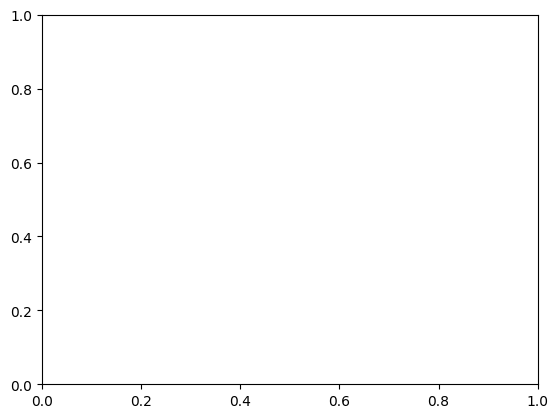

In [ ]:
coffee.plot(x='Units Sold', y='price', kind='scatter')
plt.title('Units Sold vs Price')
plt.xlabel('Units Sold')
plt.ylabel('Price')
plt.show()
plt.title('Units Sold vs Price')
plt.xlabel('Units Sold')
plt.ylabel('Price')
plt.show()